<a href="https://colab.research.google.com/github/siraj122006-2/student/blob/main/Student_Analysis_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import files
uploaded=files.upload()

Saving Student mark.csv to Student mark (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv('Student mark.csv')
print(df.head())

      Name  Tamil  English  Maths  science  Social  Evs  Computer
0    siraj     96       90     98      100      89   92        98
1    raman     91       83     93       76      97   88        79
2   suriya     92       89    100       98      90   96        86
3  praveen     88       97     76       93      83   91        67
4     alan     56       61     48       64      51   40        84


In [ ]:
subjects = ['Tamil', 'English', 'Maths', 'science', 'Social','Evs','Computer']
df['Total_Marks'] = df [subjects].sum(axis=1)
df['Average'] = df [subjects].mean(axis=1)
print(df[['Name', 'Total_Marks', 'Average']])

          Name  Total_Marks    Average
0        siraj          663  94.714286
1        raman          607  86.714286
2       suriya          651  93.000000
3      praveen          595  85.000000
4         alan          404  57.714286
5  Siva  kumar          174  24.857143


In [ ]:
def assign_grade (avg):
  if avg >= 90:
    return 'A+'
  elif avg >= 80:
    return 'A'
  elif avg >= 70:
    return 'B'
  elif avg >= 60:
    return 'C'
  elif avg >= 50:
    return 'D'
  else:
    return 'F'
df['Grade']= df ['Average'].apply(assign_grade)
df['Status'] =np.where(df ['Average'] >= 50, 'Pass', 'Fail')
print(df[['Name', 'Average', 'Grade', 'Status']])

          Name    Average Grade Status
0        siraj  94.714286    A+   Pass
1        raman  86.714286     A   Pass
2       suriya  93.000000    A+   Pass
3      praveen  85.000000     A   Pass
4         alan  57.714286     D   Pass
5  Siva  kumar  24.857143     F   Fail


In [ ]:
topper =df.loc[df['Average'].idxmax()]

print("Top Performer")

print("Name:", topper ['Name'])

print("Average:", topper ['Average'])

print("Grade:", topper ['Grade'])

Top Performer
Name: siraj
Average: 94.71428571428571
Grade: A+


In [ ]:
weak_students= df[df['Status'] =='Fail']
print("Weak Students")
print(weak_students [['Name', 'Average']])

Weak Students
          Name    Average
5  Siva  kumar  24.857143


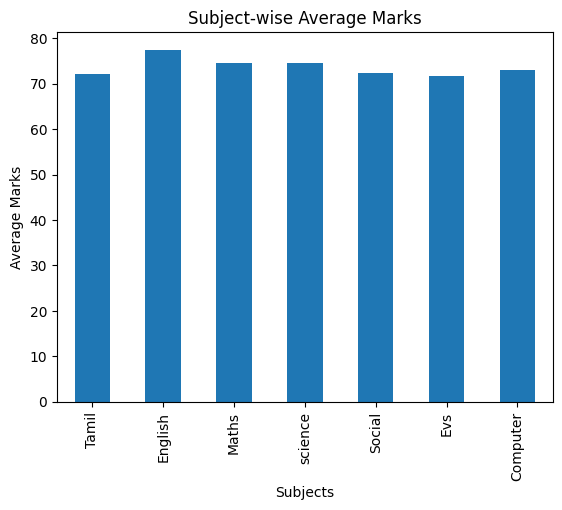

In [ ]:
subject_avg=df[['Tamil', 'English', 'Maths', 'science', 'Social','Evs','Computer']].mean()

subject_avg.plot(kind='bar')

plt.title("Subject-wise Average Marks")

plt.xlabel("Subjects")

plt.ylabel("Average Marks")

plt.show()

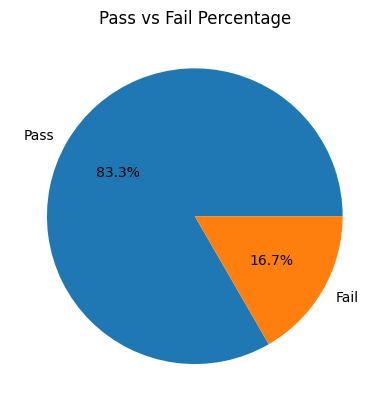

In [ ]:
status_count = df['Status'].value_counts()

plt.pie(status_count,
      labels=status_count.index,
      autopct='%1.1f%%')
plt.title("Pass vs Fail Percentage")
plt.show()

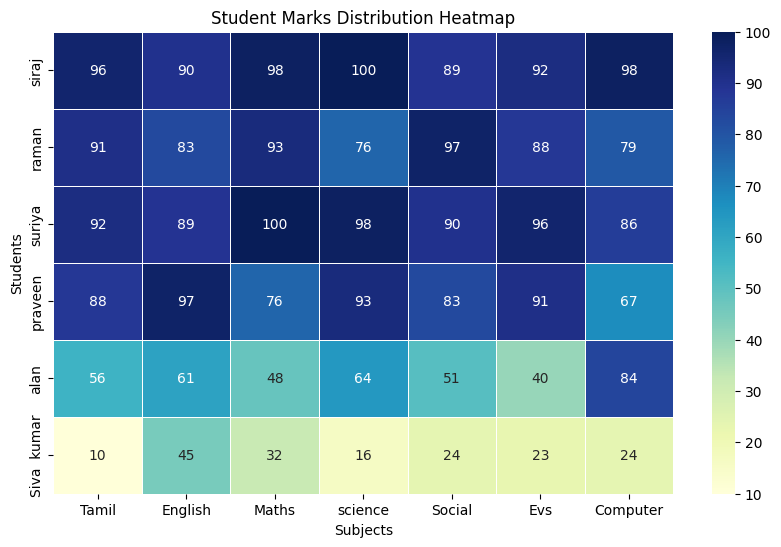

In [ ]:
# 2. Student Marks Heatmap
plt.figure(figsize=(10, 6))

# Setting Student_name as the index so it shows on the y-axis
marks_heatmap_df = df.set_index('Name')[['Tamil', 'English', 'Maths', 'science', 'Social','Evs','Computer']]

# Generating the heatmap
sns.heatmap(marks_heatmap_df, annot=True, cmap='YlGnBu', fmt="g", linewidths=0.5)

plt.title('Student Marks Distribution Heatmap')
plt.ylabel('Students')
plt.xlabel('Subjects')
plt.show()

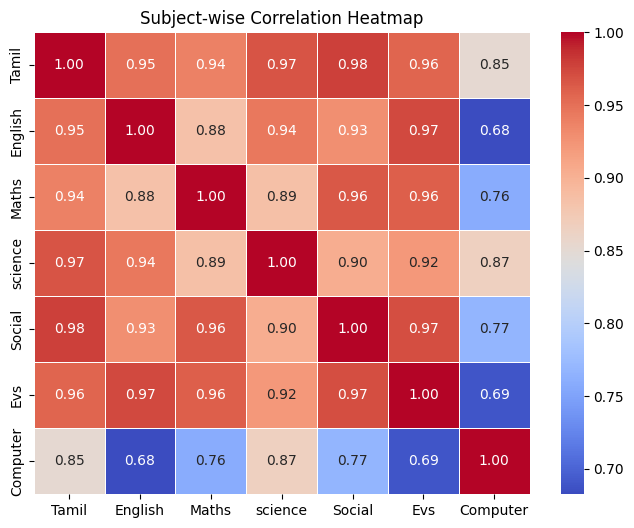

In [ ]:
# 1. Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Subsetting only the subject marks columns for correlation
subjects_df = df[['Tamil', 'English','Maths','science','Social','Evs','Computer' ]]
correlation_matrix = subjects_df.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Subject-wise Correlation Heatmap')
plt.show()

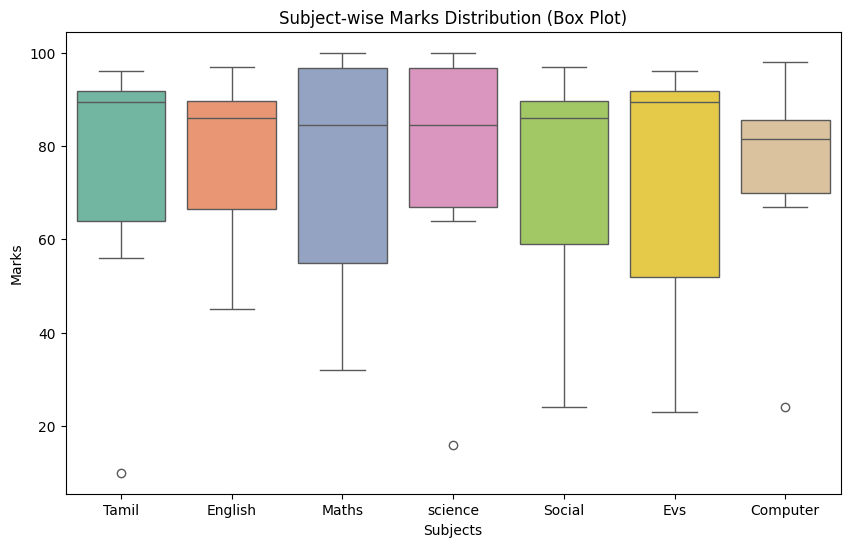

In [ ]:
# 3. Box Plot for Subject Marks Distribution
plt.figure(figsize=(10, 6))

# Melting or selecting data so seaborn can plot multiple columns easily
sns.boxplot(data=df[['Tamil', 'English', 'Maths', 'science', 'Social','Evs','Computer']], palette='Set2')

plt.title('Subject-wise Marks Distribution (Box Plot)')
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.show()

In [ ]:


print("Highest Performing Subject:", subject_avg.idxmax())

print("Lowest Performing Subject:", subject_avg.idxmin())

print("Pass Percentage:", round((df['Status']=='Pass').mean()*100,2),"%")

print("Class Average:", round (df ['Average'].mean(),2))

Highest Performing Subject: English
Lowest Performing Subject: Evs
Pass Percentage: 83.33 %
Class Average: 73.67
